# 요금제 EDA

`data/final/`의 최종 요금제·혜택 CSV를 한 번에 요약하지 않고, 한 항목씩 찍어보면서
다음 phase(페르소나 재정의 -> 합성 유저 데이터)에 쓸 근거를 쌓는다.

컬럼 의미는 `docs/컬럼_명세서.md`에 정리되어 있고, 특히 아래 두 가지를 주의한다.
- 가격 비교는 `monthly_fee`(정가)가 아니라 `discounted_fee`(실제 납부액)로 한다.
- `data_gb`가 비어 있으면 결측이 아니라 무제한이다(`data_unlimited`로 따로 본다).

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# notebooks/ 에서 실행돼도 src/schema.py를 import할 수 있게 경로를 잡는다.
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BASE_DIR / "src"))
from schema import final_path  # noqa: E402

pd.set_option("display.max_columns", 50)
plans = pd.read_csv(final_path("통신요금제_통합데이터_최종.csv"), encoding="utf-8-sig")
benefits = pd.read_csv(final_path("통신요금제_혜택상세_최종.csv"), encoding="utf-8-sig")
plans.shape, benefits.shape

((2695, 39), (4824, 13))

In [2]:
plans.head(3)

,carrier_type,host_mno,mvno_brand,plan_id,base_plan_id,plan_id_type,plan_name,selected_option,plan_category,is_online_only,age_condition,network_gen,base_data_gb,extra_data_gb,data_gb,data_unlimited,data_throttle_speed,daily_data_gb,base_tethering_gb,extra_tethering_gb,tethering_gb,voice_unlimited,voice_minutes,voice_extra_minutes,sms_unlimited,sms_count,monthly_fee,discounted_fee,discount_type,discount_period_months,benefit_count,ott_option_count,ott_options,membership_grade,smart_device_benefit,extra_data_benefit,gift_benefit,source_url,crawled_at
0,MNO,KT,NaN,1691_초이스 더블,1691_초이스 더블,official_code,초이스 더블,NaN,KT-통합요금제,False,NaN,5G,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,True,NaN,300.0,True,NaN,120000,90000.0,선택약정 25% 할인,NaN,6,1,디즈니+,VVIP,스마트기기 또는 데이터 쉐어링 스마트기기 월정액 1회선 / 데이터 쉐어링 1회선 할인,공유데이터 90GB,NaN,https://product.kt.com/wDic/productDetail.do?I...,2026-08-01T08:13:49.536956+00:00
1,MNO,KT,NaN,1691_초이스 더블_만 34세 이하,1691_초이스 더블,official_code,초이스 더블,NaN,KT-통합요금제,False,만 34세 이하,5G,NaN,NaN,NaN,True,100Kbps,NaN,90.0,90.0,180.0,True,NaN,300.0,True,NaN,120000,90000.0,선택약정 25% 할인,NaN,7,1,디즈니+,VVIP,스마트기기 또는 데이터 쉐어링 스마트기기 월정액 1회선 / 데이터 쉐어링 1회선 할인,공유데이터 90GB | 만 34세 이하 +90GB,NaN,https://product.kt.com/wDic/productDetail.do?I...,2026-08-01T08:13:49.536956+00:00
2,MNO,KT,NaN,1691_초이스 더블_만 65세 이상,1691_초이스 더블,official_code,초이스 더블,NaN,KT-통합요금제,False,만 65세 이상,5G,NaN,NaN,NaN,True,100Kbps,NaN,90.0,45.0,135.0,True,NaN,300.0,True,NaN,120000,90000.0,선택약정 25% 할인,NaN,8,1,디즈니+,VVIP,스마트기기 또는 데이터 쉐어링 스마트기기 월정액 1회선 / 데이터 쉐어링 1회선 할인,공유데이터 90GB | 만 65세 이상 +45GB,NaN,https://product.kt.com/wDic/productDetail.do?I...,2026-08-01T08:13:49.536956+00:00


## 1. 통신사/유형 분포

In [3]:
plans["carrier_type"].value_counts()

carrier_type
MVNO    2201
MNO      494
Name: count, dtype: int64

In [4]:
plans["host_mno"].value_counts()

host_mno
LGU+    1020
KT       986
SKT      689
Name: count, dtype: int64

In [5]:
# MVNO만 골라 브랜드 상위 15개 - 알뜰폰 시장이 특정 브랜드에 쏠려 있는지 본다
plans.loc[plans["carrier_type"] == "MVNO", "mvno_brand"].value_counts().head(15)

mvno_brand
티플러스        221
프리티         181
스마텔         173
아이즈모바일      170
이야기모바일      160
모빙          150
SK7모바일      121
KT스카이라이프     85
고고모바일        85
에이모바일        82
이지모바일        79
더원모바일        77
KG모바일        76
리브모바일        74
U+유모바일       60
Name: count, dtype: int64

In [6]:
plans["network_gen"].value_counts()

network_gen
LTE    1678
5G     1017
Name: count, dtype: int64

## 2. 가격 (`discounted_fee` = 실제 납부액, `monthly_fee`는 정가라 비교엔 안 씀)

In [7]:
plans["discounted_fee"].describe()

count     2649.000000
mean     24122.951680
std      23258.905281
min          0.000000
25%       8800.000000
50%      17600.000000
75%      30800.000000
max      97500.000000
Name: discounted_fee, dtype: float64

In [8]:
plans.groupby("carrier_type")["discounted_fee"].describe()

,count,mean,std,min,25%,50%,75%,max
carrier_type,,,,,,,,
MNO,448.0,62164.026786,26552.530992,8992.0,37500.0,67500.0,82500.0,97500.0
MVNO,2201.0,16379.925034,12378.200940,0.0,6900.0,14500.0,23000.0,65890.0


In [9]:
plans.groupby("host_mno")["discounted_fee"].describe()

,count,mean,std,min,25%,50%,75%,max
host_mno,,,,,,,,
KT,986.0,30868.074037,25279.416187,0.0,14000.0,22000.0,40700.0,97500.0
LGU+,974.0,18518.995893,19533.607457,0.0,4665.0,14000.0,25075.0,97500.0
SKT,689.0,22392.272859,22692.079907,10.0,7990.0,15180.0,27500.0,96750.0


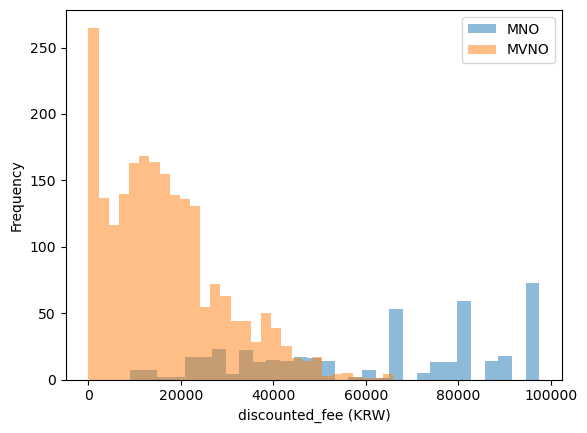

In [10]:
fig, ax = plt.subplots()
for carrier, group in plans.groupby("carrier_type"):
    group["discounted_fee"].dropna().plot(kind="hist", bins=30, alpha=0.5, ax=ax, label=carrier)
ax.set_xlabel("discounted_fee (KRW)")
ax.legend()
plt.show()

## 3. 데이터 제공량 (`data_gb`가 비면 결측이 아니라 무제한 -> `data_unlimited`로 따로 본다)

In [11]:
# carrier_type별 데이터 무제한 비율
plans.groupby("carrier_type")["data_unlimited"].mean()

carrier_type
MNO     0.595142
MVNO    0.000000
Name: data_unlimited, dtype: float64

In [12]:
# 무제한 제외(정량 요금제만) data_gb 분포
metered = plans.loc[~plans["data_unlimited"].fillna(False)]
metered.groupby("carrier_type")["data_gb"].describe()

,count,mean,std,min,25%,50%,75%,max
carrier_type,,,,,,,,
MNO,192.0,41.748698,57.855671,0.244,6.0,15.0,50.0,300.0
MVNO,2201.0,29.833238,43.872357,0.098,7.0,11.0,17.0,300.0


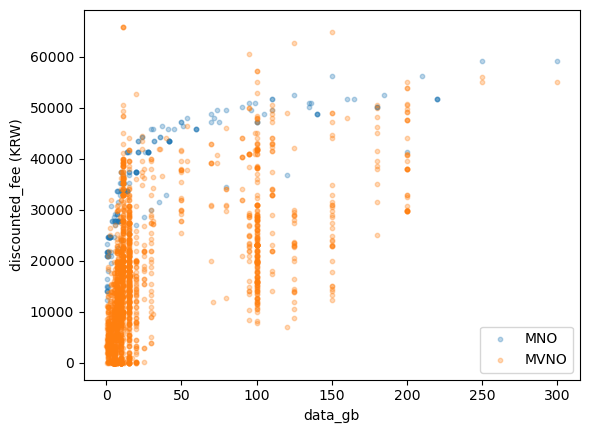

In [13]:
fig, ax = plt.subplots()
for carrier, group in metered.groupby("carrier_type"):
    ax.scatter(group["data_gb"], group["discounted_fee"], alpha=0.3, s=10, label=carrier)
ax.set_xlabel("data_gb")
ax.set_ylabel("discounted_fee (KRW)")
ax.legend()
plt.show()

## 4. 통화·문자 (대부분 무제한일 것으로 예상 - 실제로 얼마나인지 확인)

In [14]:
plans.groupby("carrier_type")[["voice_unlimited", "sms_unlimited"]].mean()

,voice_unlimited,sms_unlimited
carrier_type,,
MNO,0.949393,0.935223
MVNO,0.521127,0.503862


In [15]:
# 음성이 무제한이 아닌 요금제만 - 몇 분이나 주는지 (제한형 요금제의 실제 스펙)
plans.loc[~plans["voice_unlimited"].fillna(False), "voice_minutes"].describe()

count     943.000000
mean      301.599152
std       572.199584
min         2.000000
25%       100.000000
50%       200.000000
75%       300.000000
max      9997.000000
Name: voice_minutes, dtype: float64

## 5. 연령 조건 (`age_condition`, 정규화된 값 - schema.normalize_age_condition 적용 후)

In [16]:
# 일반(연령 무관) 요금제 비율
(plans["age_condition"].fillna("") == "").mean()

np.float64(0.8953617810760668)

In [17]:
plans.loc[plans["age_condition"].fillna("") != "", "age_condition"].value_counts()

age_condition
만 34세 이하    98
만 65세 이상    60
만 18세 이하    58
만 75세 이상    49
만 12세 이하    14
만 70세 이상     1
만 80세 이상     1
현역병사         1
Name: count, dtype: int64

In [18]:
# 연령 조건 요금제가 MNO/MVNO 어느 쪽에 몰려 있는지 - 페르소나의 연령x통신사 선호 조합이
# 실제로 가입 가능한 조합인지 확인하는 목적
restricted = plans.loc[plans["age_condition"].fillna("") != ""]
pd.crosstab(restricted["age_condition"], restricted["carrier_type"])

carrier_type,MNO
age_condition,
만 12세 이하,14
만 18세 이하,58
만 34세 이하,98
만 65세 이상,60
만 70세 이상,1
만 75세 이상,49
만 80세 이상,1
현역병사,1


## 6. 혜택 (요금제 테이블의 요약 컬럼 + benefits.csv 상세)

In [19]:
plans["ott_option_count"].value_counts().sort_index()

ott_option_count
0    2433
1     106
2      33
3      94
4      29
Name: count, dtype: int64

In [20]:
plans["membership_grade"].value_counts()

membership_grade
VIP     156
VVIP    126
Name: count, dtype: int64

In [21]:
benefits["benefit_category"].value_counts()

benefit_category
사은품/페이백    2537
추가데이터       609
OTT/구독      570
기타          498
스마트기기       328
멤버십         282
Name: count, dtype: int64

In [22]:
# benefit_value_won은 일부만 채워진다(컬럼 명세서 확인됨) - 채움 비율과
# 채워진 값의 분포를 분리해서 봐야 평균을 오독하지 않는다
print("채움 비율:", benefits["benefit_value_won"].notna().mean())
benefits["benefit_value_won"].dropna().describe()

채움 비율: 0.25538971807628524


count      1232.000000
mean      22072.248377
std       29401.073162
min           0.000000
25%        5000.000000
50%       10000.000000
75%       20000.000000
max      180000.000000
Name: benefit_value_won, dtype: float64

## 7. 요금제 개수 (행 수 vs 실제 요금제 수)

In [23]:
# 행 수(택1 전개 포함) vs 실제 요금제 수(base_plan_id 기준)
len(plans), plans["base_plan_id"].nunique()

(2695, 2354)